In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Flipkart_Mobiles.csv")

In [4]:
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [5]:
df.columns

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3071 non-null   object 
 4   Storage         3075 non-null   object 
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


In [7]:
df.isnull().sum()

Brand               0
Model               0
Color               0
Memory             43
Storage            39
Rating            144
Selling Price       0
Original Price      0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

Brand             0
Model             0
Color             0
Memory            0
Storage           0
Rating            0
Selling Price     0
Original Price    0
dtype: int64

In [10]:
df = df.drop_duplicates()

In [11]:
# Here we are extracting only digits from ram so we can perform operations on that
df['RAM_GB'] = df['Memory'].str.extract(r'(\d+)').astype(int)
df['Storage_GB'] = df['Storage'].str.extract(r'(\d+)').astype(int)

In [12]:
#Create Discount & Discount Percentage
df['Discount'] = df['Original Price'] - df['Selling Price']
df['Discount_Pct'] = (df['Discount'] / df['Original Price']) * 100

In [13]:
## Building Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df[['RAM_GB']]
y = df['Selling Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred = model_simple.predict(X_test)

print("Slope (b1):", model_simple.coef_)
print("Intercept (b0):", model_simple.intercept_)
print("R²:", r2_score(y_test, y_pred))


Slope (b1): [-31.37600431]
Intercept (b0): 24305.52699184661
R²: 0.005934879559606476


In [16]:
check = model_simple.predict(pd.DataFrame({'RAM_GB':[128]})) ##just to avoid that error

print("Selling Price of Realme mobile with Ram 128GB:",int(check[0]))


###Below is same and simple one
#check = pd.DataFrame([{'RAM_GB':128}])
#price = model_simple.predict(check) ##just to avoid that error
#print("Selling Price of Realme mobile with Ram 12GB:",int(price[0]))

Selling Price of Realme mobile with Ram 128GB: 20289


In [17]:
##Multiple Linear Regression
features = ['RAM_GB','Storage_GB','Rating','Discount','Discount_Pct']
X_multi = df[features]
y = df['Selling Price']

In [20]:
## Build Model
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_m = model_multi.predict(X_test)

print(r2_score(y_test, y_pred_m))


0.4829571261481368


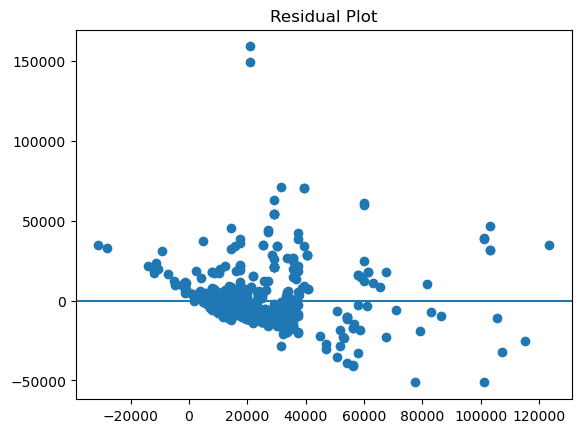

In [21]:
import matplotlib.pyplot as plt

#Residual plot
residuals = y_test - y_pred_m
plt.scatter(y_pred_m, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()


In [22]:
## Regularization (Ridge & Lasso)

# Ridge
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge.score(X_test, y_test)


0.4829087108314212

In [23]:
# Lasso 
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso.score(X_test, y_test)

0.48295658305876155

In [25]:
##Manual Gradient Descent Implementation
import numpy as np
X = df['RAM_GB'].values
y = df['Selling Price'].values

# Feature scaling
X = (X - X.mean()) / X.std()

b0 = 0
b1 = 0
alpha = 0.01
iterations = 1000

m = len(y)

for i in range(iterations):
    y_pred = b0 + b1 * X
    error = y_pred - y
    
    db0 = (1/m) * np.sum(error)
    db1 = (1/m) * np.sum(error * X)
    
    b0 -= alpha * db0
    b1 -= alpha * db1

print("b0:", b0, "b1:", b1)

b0: 23909.50731027082 b1: -2346.399086360539


In [27]:
## Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred_rf))


R²: 0.8426107774783909


In [28]:
for name, val in zip(features, rf.feature_importances_):
    print(name, ":", val)

RAM_GB : 0.10982040695708886
Storage_GB : 0.2022307931658503
Rating : 0.5484763638572655
Discount : 0.09127152142496715
Discount_Pct : 0.04820091459482824


In [30]:
## Example on Multiple Linear Regression
input_data = pd.DataFrame([{
    'RAM_GB': 12,
    'Storage_GB': 256,
    'Rating': 4.3,
    'Discount': 3000,
    'Discount_Pct': 15
}])

pred_price = rf.predict(input_data)[0]
print("Predicted Selling Price:", int(pred_price))


Predicted Selling Price: 24349
